<a href="https://colab.research.google.com/github/Chaitanya15-ai/ALFIDO/blob/main/ALFIDO_TASK_3(INSTAGRAM_DATA_ANALYSIS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET SHAPES
Users (100, 6)
Photos (257, 6)
Comments (7488, 8)
Likes (8782, 5)
Follows (7623, 5)
Photo Tags (501, 3)
Tags (21, 4)


KEY METRICS
Total Users: 100
Total Posts: 257
Total Likes: 8782
Total Comments: 7488
Average Engagement Per Post: 63.31
Best Posting Hour: 8.0
Best Posting Day: Thursday
Best Time Slot: Morning


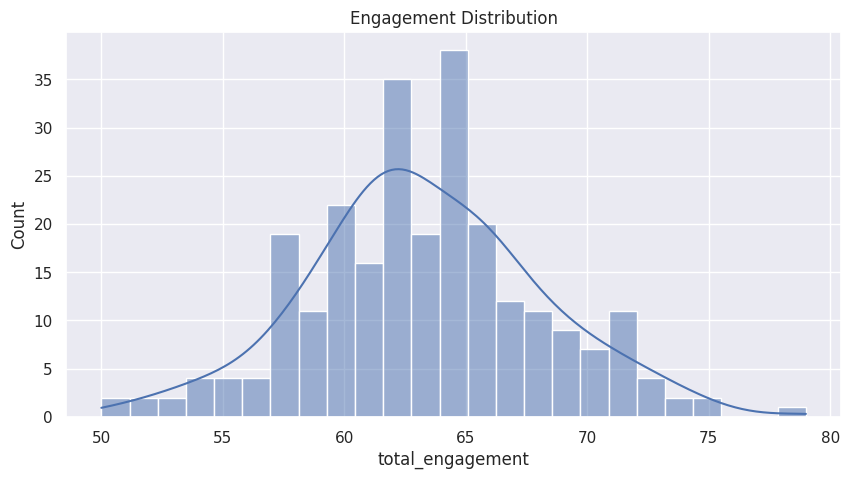

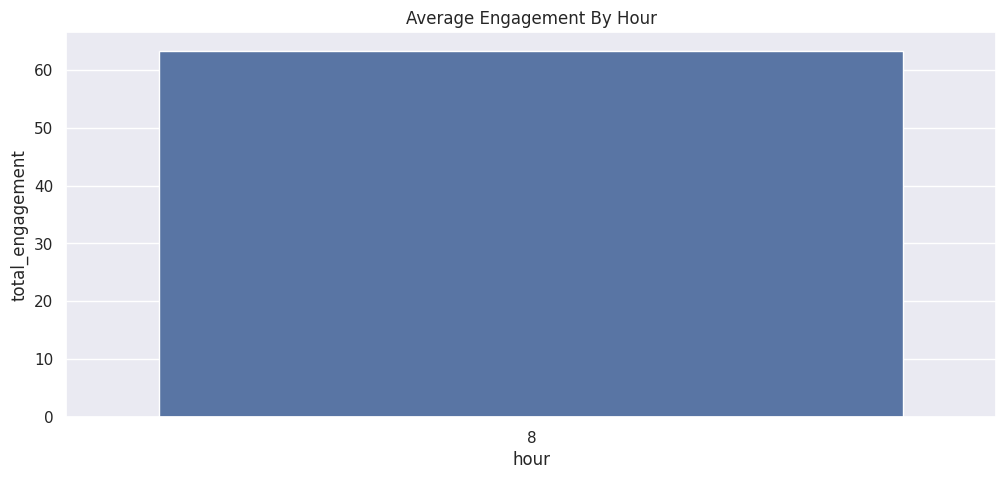

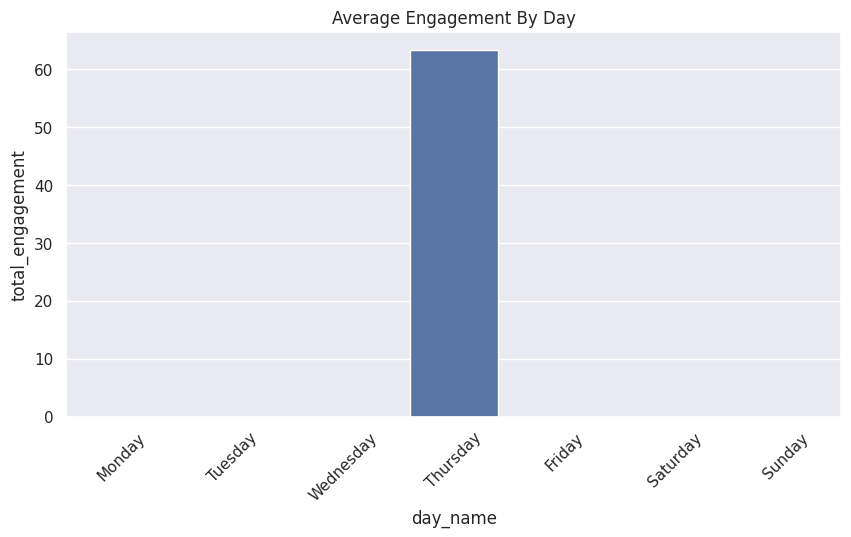

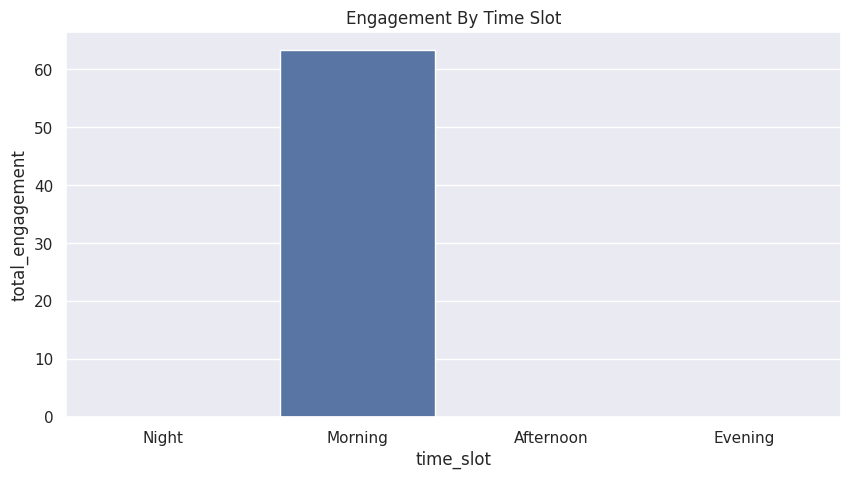

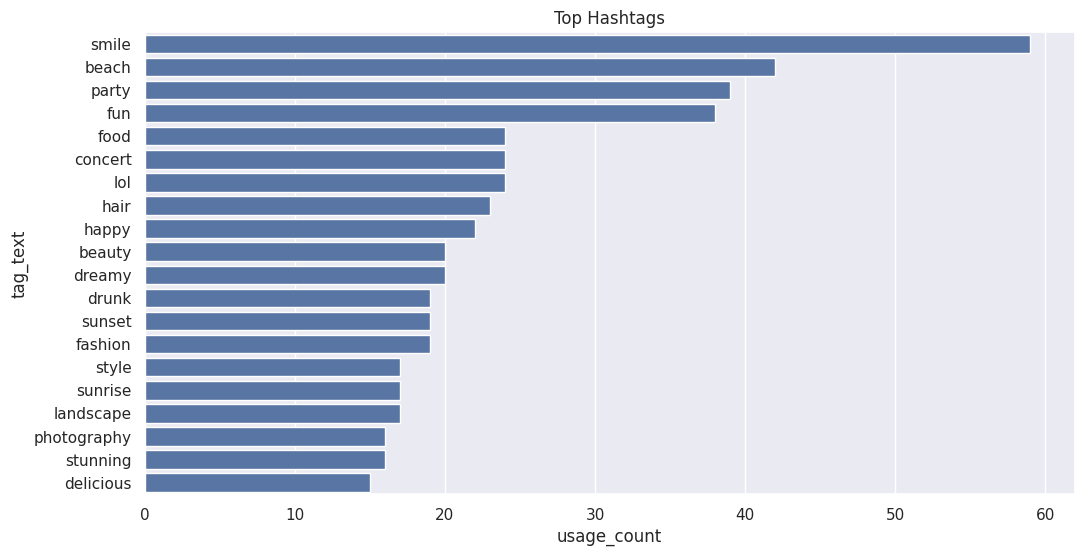

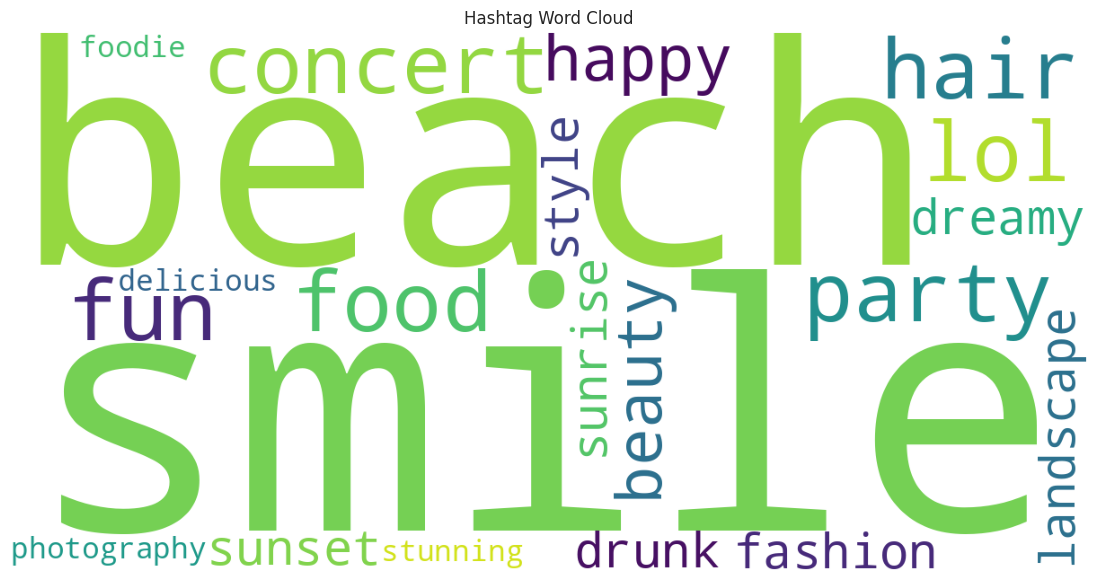

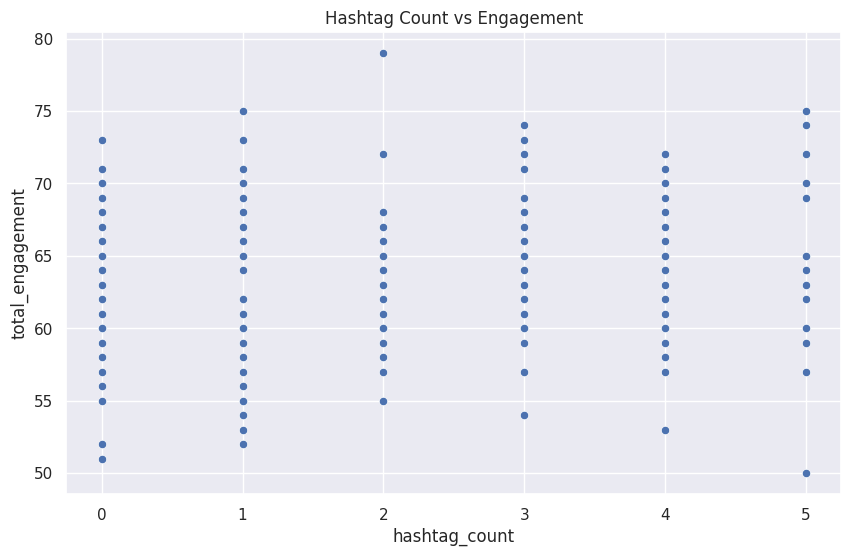

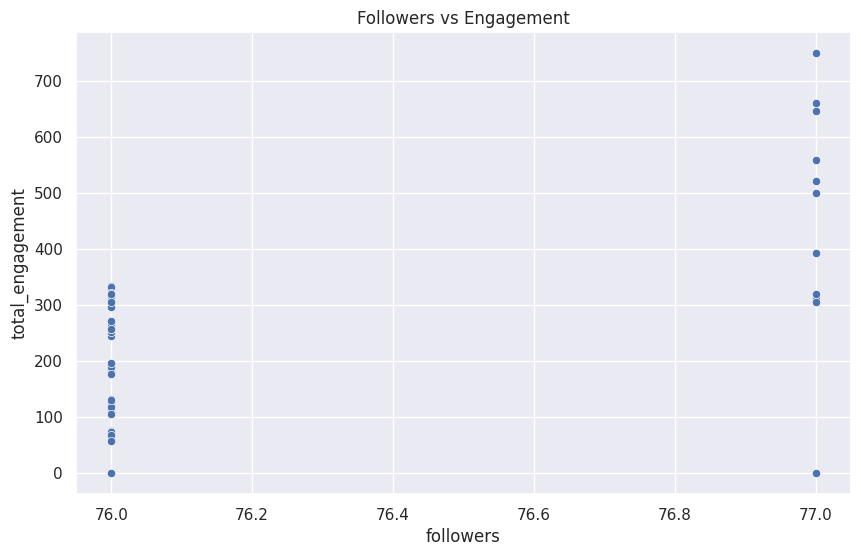

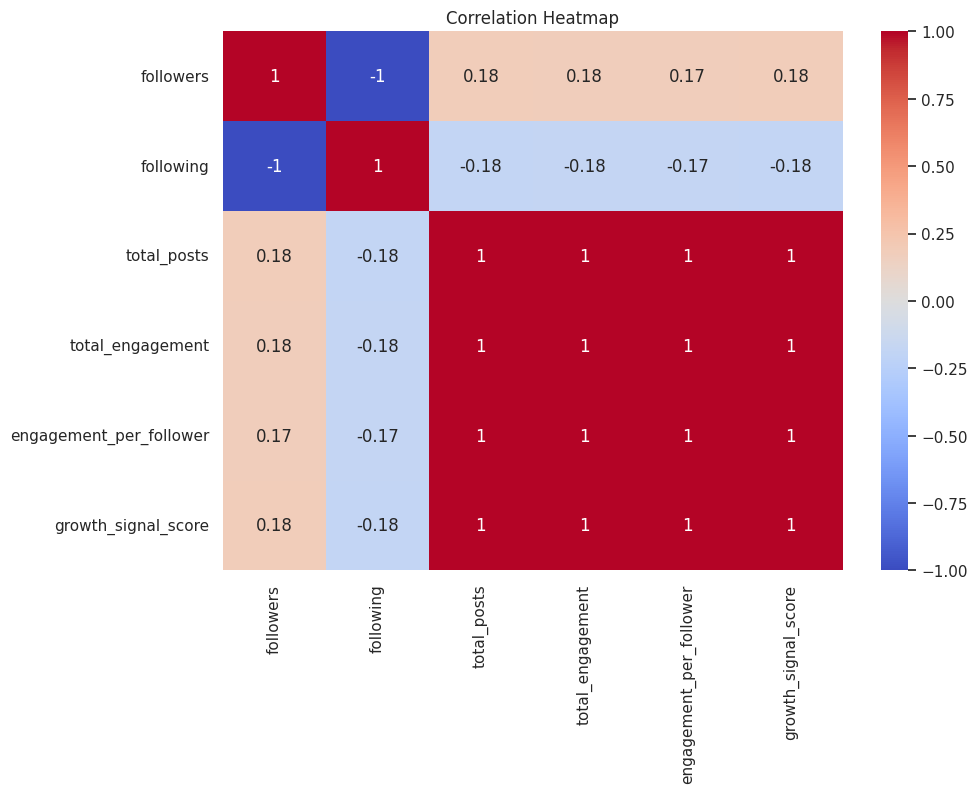

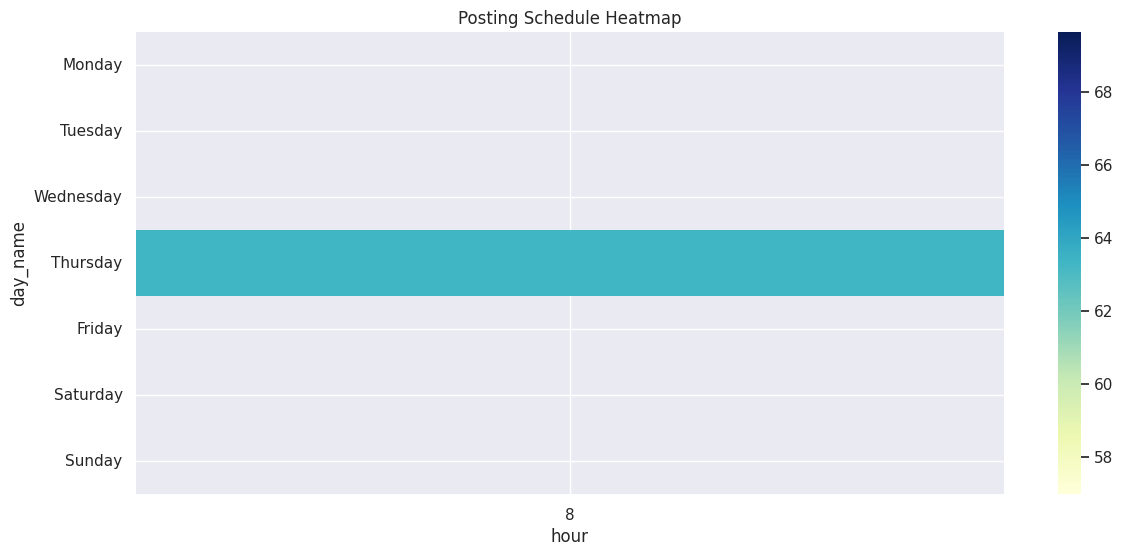


TOP 10 ACCOUNTS
                   name  followers  total_posts  total_engagement
22            Eveline95         77         12.0             749.0
87              Clint27         77         11.0             660.0
58              Cesar93         77         10.0             646.0
85  Delfina_VonRueden68         77          9.0             558.0
57            Aurelie71         77          8.0             522.0
28              Jaime53         77          8.0             500.0
76       Donald.Fritsch         77          6.0             392.0
42      Janet.Armstrong         76          5.0             334.0
51        Zack_Kemmer93         76          5.0             333.0
12          Alexandro35         76          5.0             329.0

EXECUTIVE SUMMARY
Best Posting Hour: 8.0
Best Posting Day: Thursday
Best Time Slot: Morning

ALFIDO TECH RECOMMENDATIONS
1. Post during peak engagement hours.
2. Use high-performing hashtags consistently.
3. Increase engaging visual content.
4. Encourage a

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import zipfile
import warnings

warnings.filterwarnings("ignore")

zip_path = "/content/archive (10).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("instagram_data")

comments = pd.read_csv("instagram_data/comments.csv")
follows = pd.read_csv("instagram_data/follows.csv")
likes = pd.read_csv("instagram_data/likes.csv")
photo_tags = pd.read_csv("instagram_data/photo_tags.csv")
photos = pd.read_csv("instagram_data/photos.csv")
tags = pd.read_csv("instagram_data/tags.csv")
users = pd.read_csv("instagram_data/users.csv")

comments.columns = comments.columns.str.strip()
follows.columns = follows.columns.str.strip()
likes.columns = likes.columns.str.strip()
photo_tags.columns = photo_tags.columns.str.strip()
photos.columns = photos.columns.str.strip()
tags.columns = tags.columns.str.strip()
users.columns = users.columns.str.strip()

users = users.rename(columns={
    "created time":"created_time",
    "private/public":"account_type",
    "post count":"post_count",
    "Verified status":"verified_status"
})

photos = photos.rename(columns={
    "user ID":"user_id",
    "created dat":"created_date",
    "Insta filter used":"filter_used",
    "photo type":"photo_type",
    "image link":"image_link"
})

comments = comments.rename(columns={
    "User  id":"user_id",
    "Photo id":"photo_id",
    "created Timestamp":"created_timestamp",
    "posted date":"posted_date",
    "emoji used":"emoji_used",
    "Hashtags used count":"hashtags_used_count"
})

likes = likes.rename(columns={
    "user":"user_id"
})

follows = follows.rename(columns={
    "followee":"followee"
})

photo_tags = photo_tags.rename(columns={
    "tag ID":"tag_id",
    "user id":"user_id"
})

tags = tags.rename(columns={
    "tag text":"tag_text",
    "created time":"created_time"
})

print("="*70)
print("DATASET SHAPES")
print("="*70)

for name, df in {
    "Users":users,
    "Photos":photos,
    "Comments":comments,
    "Likes":likes,
    "Follows":follows,
    "Photo Tags":photo_tags,
    "Tags":tags
}.items():
    print(name, df.shape)

photos["created_date"] = pd.to_datetime(photos["created_date"])

photos["year"] = photos["created_date"].dt.year
photos["month"] = photos["created_date"].dt.month
photos["month_name"] = photos["created_date"].dt.month_name()
photos["day_name"] = photos["created_date"].dt.day_name()
photos["hour"] = photos["created_date"].dt.hour

photos["time_slot"] = pd.cut(
    photos["hour"],
    bins=[-1,5,11,17,23],
    labels=["Night","Morning","Afternoon","Evening"]
)

likes_per_photo = likes.groupby("photo").size().reset_index(name="likes_count")

comments_per_photo = comments.groupby(
    "photo_id"
).size().reset_index(name="comments_count")

engagement = photos.merge(
    likes_per_photo,
    left_on="id",
    right_on="photo",
    how="left"
)

engagement = engagement.merge(
    comments_per_photo,
    left_on="id",
    right_on="photo_id",
    how="left"
)

engagement["likes_count"] = engagement["likes_count"].fillna(0)
engagement["comments_count"] = engagement["comments_count"].fillna(0)

engagement["total_engagement"] = (
    engagement["likes_count"] +
    engagement["comments_count"]
)

followers = follows.groupby(
    "followee"
).size().reset_index(name="followers")

followers.columns = ["id","followers"]

following = follows.groupby(
    "follower"
).size().reset_index(name="following")

following.columns = ["id","following"]

user_stats = users.merge(
    followers,
    on="id",
    how="left"
)

user_stats = user_stats.merge(
    following,
    on="id",
    how="left"
)

user_stats["followers"] = user_stats["followers"].fillna(0)
user_stats["following"] = user_stats["following"].fillna(0)

user_posts = photos.groupby(
    "user_id"
).size().reset_index(name="total_posts")

user_posts.columns = ["id","total_posts"]

user_stats = user_stats.merge(
    user_posts,
    on="id",
    how="left"
)

user_stats["total_posts"] = user_stats["total_posts"].fillna(0)

user_engagement = engagement.groupby(
    "user_id"
)["total_engagement"].sum().reset_index()

user_engagement.columns = ["id","total_engagement"]

user_stats = user_stats.merge(
    user_engagement,
    on="id",
    how="left"
)

user_stats["total_engagement"] = user_stats["total_engagement"].fillna(0)

user_stats["engagement_per_follower"] = np.where(
    user_stats["followers"] > 0,
    user_stats["total_engagement"] /
    user_stats["followers"],
    0
)

user_stats["growth_signal_score"] = (
    user_stats["followers"] * 0.4 +
    user_stats["total_engagement"] * 0.4 +
    user_stats["engagement_per_follower"] * 0.2
)

photo_hashtag_count = photo_tags.groupby(
    "photo"
).size().reset_index(name="hashtag_count")

engagement = engagement.merge(
    photo_hashtag_count,
    left_on="id",
    right_on="photo",
    how="left"
)

engagement["hashtag_count"] = engagement["hashtag_count"].fillna(0)

tag_usage = photo_tags.groupby(
    "tag_id"
).size().reset_index(name="usage_count")

tag_usage.columns = ["id","usage_count"]

tag_usage = tag_usage.merge(
    tags,
    on="id"
)

top_hashtags = tag_usage.sort_values(
    "usage_count",
    ascending=False
)

hourly_engagement = engagement.groupby(
    "hour"
)["total_engagement"].mean().reset_index()

daily_engagement = engagement.groupby(
    "day_name"
)["total_engagement"].mean().reset_index()

timeslot_engagement = engagement.groupby(
    "time_slot"
)["total_engagement"].mean().reset_index()

best_hour = hourly_engagement.loc[
    hourly_engagement["total_engagement"].idxmax()
]

best_day = daily_engagement.loc[
    daily_engagement["total_engagement"].idxmax()
]

best_slot = timeslot_engagement.loc[
    timeslot_engagement["total_engagement"].idxmax()
]

print("\n")
print("="*70)
print("KEY METRICS")
print("="*70)

print("Total Users:", len(users))
print("Total Posts:", len(photos))
print("Total Likes:", len(likes))
print("Total Comments:", len(comments))
print("Average Engagement Per Post:", round(engagement["total_engagement"].mean(),2))
print("Best Posting Hour:", best_hour["hour"])
print("Best Posting Day:", best_day["day_name"])
print("Best Time Slot:", best_slot["time_slot"])

plt.figure(figsize=(10,5))
sns.histplot(engagement["total_engagement"], bins=25, kde=True)
plt.title("Engagement Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=hourly_engagement,x="hour",y="total_engagement")
plt.title("Average Engagement By Hour")
plt.show()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

daily_engagement["day_name"] = pd.Categorical(
    daily_engagement["day_name"],
    categories=day_order,
    ordered=True
)

daily_engagement = daily_engagement.sort_values("day_name")

plt.figure(figsize=(10,5))
sns.barplot(data=daily_engagement,x="day_name",y="total_engagement")
plt.xticks(rotation=45)
plt.title("Average Engagement By Day")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=timeslot_engagement,x="time_slot",y="total_engagement")
plt.title("Engagement By Time Slot")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_hashtags.head(20),
    x="usage_count",
    y="tag_text"
)
plt.title("Top Hashtags")
plt.show()

word_text = " ".join(top_hashtags["tag_text"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(word_text)

plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Hashtag Word Cloud")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=engagement,
    x="hashtag_count",
    y="total_engagement"
)
plt.title("Hashtag Count vs Engagement")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=user_stats,
    x="followers",
    y="total_engagement"
)
plt.title("Followers vs Engagement")
plt.show()

corr_data = user_stats[
    [
        "followers",
        "following",
        "total_posts",
        "total_engagement",
        "engagement_per_follower",
        "growth_signal_score"
    ]
]

plt.figure(figsize=(10,7))
sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

hour_day_matrix = engagement.pivot_table(
    values="total_engagement",
    index="day_name",
    columns="hour",
    aggfunc="mean"
)

hour_day_matrix = hour_day_matrix.reindex(day_order)

plt.figure(figsize=(14,6))
sns.heatmap(hour_day_matrix,cmap="YlGnBu")
plt.title("Posting Schedule Heatmap")
plt.show()

top_users = user_stats.sort_values(
    "total_engagement",
    ascending=False
).head(10)

print("\nTOP 10 ACCOUNTS")
print(top_users[
    [
        "name",
        "followers",
        "total_posts",
        "total_engagement"
    ]
])

print("\nEXECUTIVE SUMMARY")
print("Best Posting Hour:", best_hour["hour"])
print("Best Posting Day:", best_day["day_name"])
print("Best Time Slot:", best_slot["time_slot"])

print("\nALFIDO TECH RECOMMENDATIONS")
print("1. Post during peak engagement hours.")
print("2. Use high-performing hashtags consistently.")
print("3. Increase engaging visual content.")
print("4. Encourage audience interaction through captions.")
print("5. Collaborate with high-engagement creators.")

calendar = pd.DataFrame({
    "Day":["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    "Recommended Content":[
        "Industry Tips",
        "Carousel",
        "Educational Content",
        "Reels",
        "Case Study",
        "Trending Content",
        "Community Post"
    ]
})

print("\nCONTENT CALENDAR")
print(calendar)